In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SPLIT_DIR = BASE_DIR / "data" / "splits"
MODEL_DIR = BASE_DIR / "models"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print("Test dataset:", test_df.shape)

test_df.head()

Test dataset: (5201, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,productDisplayName,image_path,image_exists
0,7435,Men,Apparel,Topwear,Tshirts,Red,Summer,Casual,Proline Men Red & Navy Checked Polo T-shirt,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
1,40118,Men,Apparel,Topwear,Tshirts,Black,Summer,Casual,ADIDAS Men Red T-shirt,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
2,12753,Men,Apparel,Bottomwear,Jeans,Black,Fall,Casual,Spykar Men Ep Jeans Black Jeans,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
3,50986,Women,Apparel,Innerwear,Briefs,Maroon,Summer,Casual,Enamor Women Plum Briefs,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
4,47978,Women,Accessories,Watches,Watches,Purple,Winter,Casual,Helix Women Purple Dial Watch,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True


In [4]:
with open(MODEL_DIR / "articleType_class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)

idx_to_class = {
    int(v): k
    for k, v in class_to_idx.items()
}

num_classes = len(class_to_idx)

print("Classes:", num_classes)
print(idx_to_class)

Classes: 23
{0: 'Backpacks', 1: 'Belts', 2: 'Briefs', 3: 'Casual Shoes', 4: 'Flats', 5: 'Flip Flops', 6: 'Formal Shoes', 7: 'Handbags', 8: 'Heels', 9: 'Jeans', 10: 'Kurtas', 11: 'Perfume and Body Mist', 12: 'Sandals', 13: 'Shirts', 14: 'Shorts', 15: 'Socks', 16: 'Sports Shoes', 17: 'Sunglasses', 18: 'Tops', 19: 'Trousers', 20: 'Tshirts', 21: 'Wallets', 22: 'Watches'}


In [5]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
class WardrobeDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_path = row["image_path"]

        label_name = row["articleType"]
        label = self.class_to_idx[label_name]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [7]:
test_dataset = WardrobeDataset(
    test_df,
    class_to_idx,
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Test batches:", len(test_loader))

Test batches: 163


In [8]:
model = models.mobilenet_v2(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "mobilenetv2_articleType_best.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model loaded successfully.")

C:\Users\chathudu sahassara\AppData\Local\Temp\ipykernel_47628\1015215851.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Model loaded successfully.


In [9]:
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

print("Prediction completed.")

Prediction completed.


In [10]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=[
        idx_to_class[i]
        for i in range(num_classes)
    ]
)

print(report)

                       precision    recall  f1-score   support

            Backpacks       0.96      0.95      0.96       108
                Belts       1.00      0.99      1.00       122
               Briefs       0.98      1.00      0.99       127
         Casual Shoes       0.83      0.84      0.84       427
                Flats       0.61      0.19      0.29        75
           Flip Flops       0.85      0.93      0.89       137
         Formal Shoes       0.73      0.98      0.83        95
             Handbags       0.96      0.98      0.97       264
                Heels       0.76      0.93      0.84       199
                Jeans       0.88      0.92      0.90        90
               Kurtas       0.94      0.99      0.96       277
Perfume and Body Mist       1.00      1.00      1.00        90
              Sandals       0.93      0.80      0.86       134
               Shirts       0.97      0.99      0.98       482
               Shorts       0.96      0.96      0.96  

In [11]:
accuracy = np.mean(
    np.array(all_labels) == np.array(all_predictions)
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9227071716977504


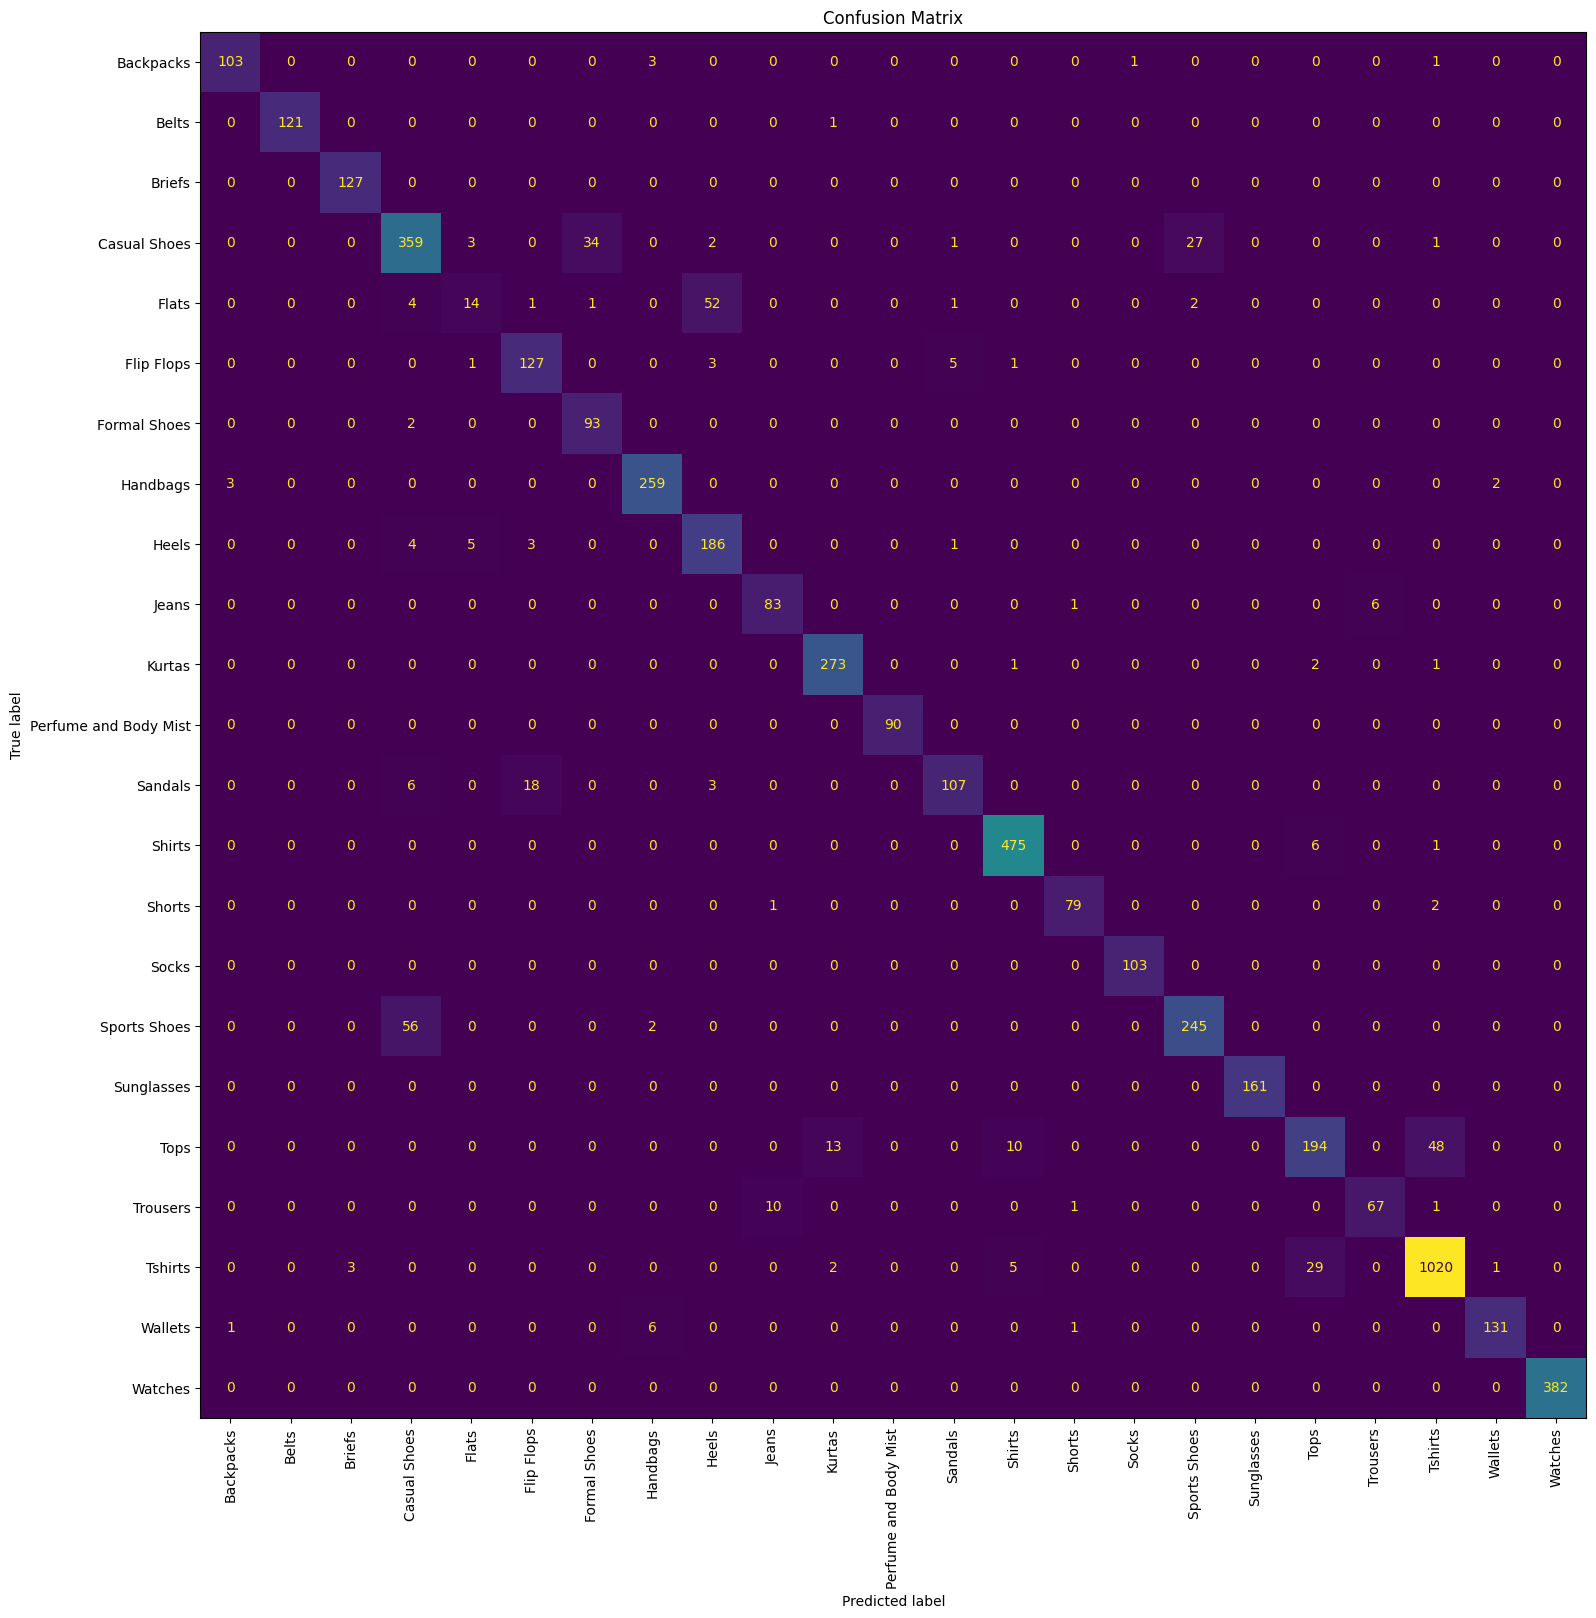

In [12]:
cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        idx_to_class[i]
        for i in range(num_classes)
    ]
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

In [13]:
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

report_path = OUTPUT_DIR / "classification_report.txt"

with open(report_path, "w") as f:
    f.write(report)

print("Classification report saved to:", report_path)

Classification report saved to: D:\Git\eshani-2026\e_wardrobe_ai\outputs\classification_report.txt
